# 2b – Blick in den Index: DB-Rohdaten & Retrieval sichtbar machen

Dieses Notebook **verändert nichts** – es öffnet den fertigen Index nur lesend und macht
zwei Dinge sichtbar, die sonst verborgen bleiben:

1. **Wie die Vektor-DB aussieht** – IDs, Metadaten, Vektoren, Klartext
2. **Was `similarity_search` tut** – dieselbe Suche, aber mit Distanz-Score pro Treffer

> **Voraussetzung:** Notebook 1 lief, `./chroma_db` existiert. Ein laufender Kernel von
> Notebook 2 ist *nicht* nötig – hier wird alles selbst geladen.

## Minimal-Konfiguration

Nur das, was zum Lesen des Index gebraucht wird. Das Embedding-Modell steht hier auf
`text-embedding-bge-m3` – **passend zum Manifest**, mit dem der Index gebaut wurde.

In [1]:
DB_DIR          = "./chroma_db"
COLLECTION_NAME = "langchain"
LM_STUDIO_URL   = "http://localhost:1234/v1"
EMBEDDING_MODEL = "text-embedding-bge-m3"   # muss dem Manifest entsprechen!
TOP_K           = 10

## Embedding-Modell & Vektordatenbank laden

In [2]:
import os
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma


class E5OpenAIEmbeddings(OpenAIEmbeddings):
    """Gleicher Wrapper wie in Notebook 1 – muss identisch sein, damit die
    Query-Vektoren genauso entstehen wie die Dokument-Vektoren im Index."""

    def embed_documents(self, texts):
        return super().embed_documents(["passage: " + t for t in texts])

    def embed_query(self, text):
        return super().embed_query("query: " + text)


embeddings = E5OpenAIEmbeddings(
    model=EMBEDDING_MODEL,
    api_key="lm-studio",
    base_url=LM_STUDIO_URL,
    check_embedding_ctx_length=False,
)

vectorstore = Chroma(
    collection_name=COLLECTION_NAME,
    persist_directory=DB_DIR,
    embedding_function=embeddings,
)

print(f"✅ Vektordatenbank geladen – {vectorstore._collection.count()} Chunks verfügbar.")

✅ Vektordatenbank geladen – 5961 Chunks verfügbar.


## 1 – Rohblick in die Datenbank

`col.get(...)` holt Datensätze **ohne Suche** direkt aus der Collection. So sieht ein
gespeicherter Chunk wirklich aus: eine ID, die Metadaten, der Vektor (hier bge-m3 → 1024
Dimensionen, davon die ersten fünf) und der Klartext.

In [12]:
col = vectorstore._collection
print("Anzahl Chunks:", col.count())

sample = col.get(limit=5, include=["documents", "metadatas", "embeddings"])

for i in range(len(sample["ids"])):
    vec = sample["embeddings"][i]
    print("\nID:       ", sample["ids"][i])
    print("Metadaten:", sample["metadatas"][i])
    print("Vektor:   ", len(vec), "Dim →", [round(x, 3) for x in vec[:5]], "...")
    print("Text:     ", repr(sample["documents"][i]))

Anzahl Chunks: 5961

ID:        afb94ea9-05d7-40d5-bf7a-fc8321fbefa3
Metadaten: {'author': 'Bundesministerium für Arbeit und Soziales (BMAS)', 'source': './documents/20240604-Shortpaper_Standards-fuer-KI.pdf', 'moddate': '2024-06-06T09:16:15+02:00', 'modDate': "D:20240606091615+02'00'", 'file_path': './documents/20240604-Shortpaper_Standards-fuer-KI.pdf', 'keywords': '', 'producer': 'Adobe PDF Library 24.2.23', 'creationdate': '2024-06-04T16:10:15+02:00', 'title': 'Standards für KI: Warum der AI Act nur der Anfang der europäischen KI-Regulierung ist', 'subject': '', 'total_pages': 6, 'creator': 'Acrobat PDFMaker 24 für Word', 'trapped': '', 'format': 'PDF 1.6', 'page': 0, 'creationDate': "D:20240604161015+02'00'"}
Vektor:    1024 Dim → [np.float64(-0.043), np.float64(0.009), np.float64(-0.058), np.float64(-0.008), np.float64(-0.021)] ...
Text:      '#1 – Shortpaper Standards für KI    1 \n \nStandards für KI: Warum der AI Act nur der Anfang der \neuropäischen KI-Regulierung ist \n#1 

### Und auf der Festplatte?

Die Collection ist keine einzelne Datei. In `chroma.sqlite3` liegen IDs, Text und
Metadaten (mit `sqlite3` oder „DB Browser for SQLite“ lesbar); die eigentlichen Vektoren
stecken als binärer HNSW-Index im UUID-Unterordner – bewusst nicht menschenlesbar.

In [4]:
for root, _, files in os.walk(DB_DIR):
    for f in sorted(files):
        p = os.path.join(root, f)
        print(f"{os.path.getsize(p) // 1024:>7} KB  {p}")

  61856 KB  ./chroma_db/chroma.sqlite3
  22590 KB  ./chroma_db/35fd8c25-a1a3-4496-8895-d254638555c4/data_level0.bin
      0 KB  ./chroma_db/35fd8c25-a1a3-4496-8895-d254638555c4/header.bin
    490 KB  ./chroma_db/35fd8c25-a1a3-4496-8895-d254638555c4/index_metadata.pickle
     21 KB  ./chroma_db/35fd8c25-a1a3-4496-8895-d254638555c4/length.bin
     47 KB  ./chroma_db/35fd8c25-a1a3-4496-8895-d254638555c4/link_lists.bin


## 2 – In `similarity_search` hineinschauen

`similarity_search` liefert nur die Chunks. `similarity_search_with_score` liefert
zusätzlich die **Distanz** – und die macht sichtbar, *warum* gerade diese Treffer kommen.

> Der Wert ist eine Distanz, **kein** Prozent: **kleiner = ähnlicher**. Achte auf den
> Abstand zwischen Platz 1 und Platz 10 – er zeigt, wie deutlich der Index sich „sicher“ ist.

In [22]:
frage = "Was ist eine Hochrisiko-Anwendung" #"Was verbietet der AI Act?"

# Stabile Index-Liste (0 … 5960)
all_ids    = col.get(include=[])["ids"]
idx_von_id = {cid: i for i, cid in enumerate(all_ids)}

# Rohe Chroma-Suche: liefert zusätzlich die IDs (die similarity_search verschluckt)
qv  = embeddings.embed_query(frage)
res = col.query(query_embeddings=[qv], n_results=TOP_K,
                include=["documents", "metadatas", "distances"])

print(f"Frage: {frage}\n")
print(f"{'Idx':>5}  {'Distanz':>8}  {'Quelle':<45} {'Seite':>5}  Text")
print("-" * 105)
for cid, doc, meta, dist in zip(res["ids"][0], res["documents"][0],
                                res["metadatas"][0], res["distances"][0]):
    quelle = os.path.basename(meta.get("source", "?"))
    seite  = meta.get("page", 0) + 1
    print(f"{idx_von_id[cid]:>5}  {dist:8.4f}  {quelle[:45]:<45} {seite:>5}  {repr(doc[:100])}...")

Frage: Was ist eine Hochrisiko-Anwendung

  Idx   Distanz  Quelle                                        Seite  Text
---------------------------------------------------------------------------------------------------------
 1906    0.6400  Künstliche Intelligenz im Rahmen des AI Acts    18  'Verkehr gebracht und genutzt werden, unterliegen aber besonders strengen gesetzlichen \nAnforderungen'...
 1609    0.7084  Guidelines_on_prohibited_artificial_intellige   141  'hohes Risiko für die Rechte und Freiheiten natürlicher Personen in öffentlich \nzugänglichen Räumen m'...
 1905    0.7087  Künstliche Intelligenz im Rahmen des AI Acts    18  '18 \n \n2.7.2.  Hochrisiko-KI-Systeme \nHochrisiko-KI-Systeme stellen die zweite und umfangreichste Ris'...
 1943    0.7372  Künstliche Intelligenz im Rahmen des AI Acts    23  'organisatorischer Verpflichtungen halten, die insbesondere für Hochrisiko-Anwendungen \nverbindlich s'...
 2484    0.7389  OJ_L_202401689_DE_TXT.pdf                        2

### Ähnlichkeit der Chunks visualisieren

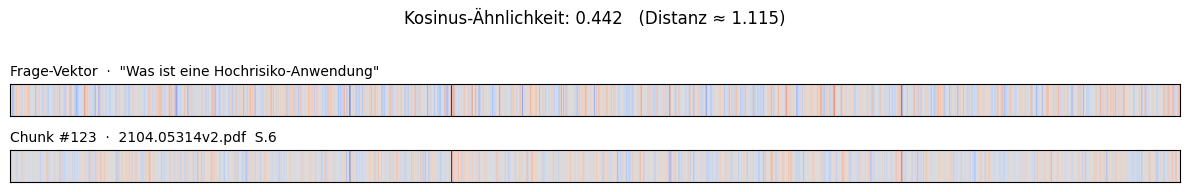


Chunk-Text:
dense feature vectors with low dimensionality. Thus, in contrast to classic text representation models, such as
one-hot encodings and bag-of-words (BoW), word embeddings overcome the problem of sparse encodings
while preserving semantic relationships between words. This means that words, which occur in similar contexts
in a corpus, are also closely positioned to each other in the vector space. On this basis, advanced language models 


In [26]:
import os, numpy as np
import matplotlib.pyplot as plt

# ▼ Welchen Chunk ansehen? Index aus der Tabelle oben (0 … 5960)
CHUNK_INDEX = 123
#frage       =  "Was verbietet der AI Act?"

all_ids = col.get(include=[])["ids"]
chunk   = col.get(ids=[all_ids[CHUNK_INDEX]],
                  include=["embeddings", "documents", "metadatas"])

chunk_vec = np.array(chunk["embeddings"][0])          # aus der DB → "passage:"-Raum
frage_vec = np.array(embeddings.embed_query(frage))   # frisch    → "query:"-Raum

cos  = float(frage_vec @ chunk_vec /
             (np.linalg.norm(frage_vec) * np.linalg.norm(chunk_vec)))
dist = 2 - 2 * cos                                    # ≈ Chroma-Distanz (quadr. L2)

meta   = chunk["metadatas"][0]
quelle = os.path.basename(meta.get("source", "?"))
seite  = meta.get("page", 0) + 1

def strich_code(ax, vec, titel):
    lim = np.abs(vec).max()
    ax.imshow(vec.reshape(1, -1), aspect="auto", cmap="coolwarm", vmin=-lim, vmax=lim)
    ax.set_title(titel, fontsize=10, loc="left")
    ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(2, 1, figsize=(12, 1.8))
strich_code(axes[0], frage_vec, f'Frage-Vektor  ·  "{frage}"')
strich_code(axes[1], chunk_vec, f"Chunk #{CHUNK_INDEX}  ·  {quelle}  S.{seite}")
fig.suptitle(f"Kosinus-Ähnlichkeit: {cos:.3f}   (Distanz ≈ {dist:.3f})", fontsize=12, y=1.04)
fig.tight_layout(); plt.show()

print(f"\nChunk-Text:\n{chunk['documents'][0]} ")

### Den Query-Vektor selbst ansehen

Genau das passiert im Hintergrund vor der Suche: die Frage wird zum Vektor. Der Wrapper
stellt automatisch `query: ` voran (deshalb taucht es im Ergebnis nicht auf).

In [17]:
qv = embeddings.embed_query(frage)
print("Query-Vektor:", len(qv), "Dimensionen")
print("Erste zehn Werte:", [round(x, 3) for x in qv[:10]])

Query-Vektor: 1024 Dimensionen
Erste zehn Werte: [0.022, 0.025, -0.034, 0.003, -0.035, 0.004, -0.017, 0.039, -0.033, 0.028]


### Export für die Webseite

In [27]:
import os, json

# ▼ Was soll in die Demo? Teilstring des Dateinamens ("" = alle), und Obergrenze
SOURCE_FILTER     = "AI_Act"   # z. B. "AI_Act"; "" nimmt alle Dokumente
MAX_EXPORT_CHUNKS = 500
NACHKOMMA         = 4          # Rundung der Vektoren – hält die Datei klein

all_ids    = col.get(include=[])["ids"]
idx_von_id = {cid: i for i, cid in enumerate(all_ids)}

meta_all = col.get(include=["metadatas"])          # leicht: nur Metadaten, keine Vektoren
gewaehlt = [cid for cid, m in zip(meta_all["ids"], meta_all["metadatas"])
            if SOURCE_FILTER in m.get("source", "")][:MAX_EXPORT_CHUNKS]

daten = col.get(ids=gewaehlt, include=["embeddings", "documents", "metadatas"])

chunks = [{
    "db_index": idx_von_id[cid],
    "quelle":   os.path.basename(m.get("source", "?")),
    "seite":    m.get("page", 0) + 1,
    "text":     doc,
    "vec":      [round(float(x), NACHKOMMA) for x in vec],
} for cid, vec, doc, m in zip(daten["ids"], daten["documents"] and daten["ids"] and daten["ids"], [], [])]  # placeholder

# (sauber ausgeschrieben:)
chunks = []
for cid, vec, doc, m in zip(daten["ids"], daten["embeddings"], daten["documents"], daten["metadatas"]):
    chunks.append({
        "db_index": idx_von_id[cid],
        "quelle":   os.path.basename(m.get("source", "?")),
        "seite":    m.get("page", 0) + 1,
        "text":     doc,
        "vec":      [round(float(x), NACHKOMMA) for x in vec],
    })

export = {
    "embedding_model": EMBEDDING_MODEL,   # exakt das Modell, das LM Studio serviert
    "query_prefix":    "query: ",         # dieselbe Konvention wie im Index
    "dims":            len(chunks[0]["vec"]),
    "anzahl":          len(chunks),
    "chunks":          chunks,
}

with open("demo_daten.json", "w", encoding="utf-8") as f:
    json.dump(export, f, ensure_ascii=False)

print(f"✅ {len(chunks)} Chunks exportiert → demo_daten.json "
      f"({os.path.getsize('demo_daten.json')/1024/1024:.2f} MB)")

✅ 500 Chunks exportiert → demo_daten.json (4.41 MB)
